# Machine Learning practical file
# Name: Ayser islam
# R.No: 230325
# B.Sc(hons.)computer science section A


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
housing=fetch_california_housing(as_frame=True)
house_price_df=housing.frame
print(f"Data loaded successfully with shape {house_price_df.shape}")
X=housing.data
y=housing.target

Data loaded successfully with shape (20640, 9)


In [ ]:
housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


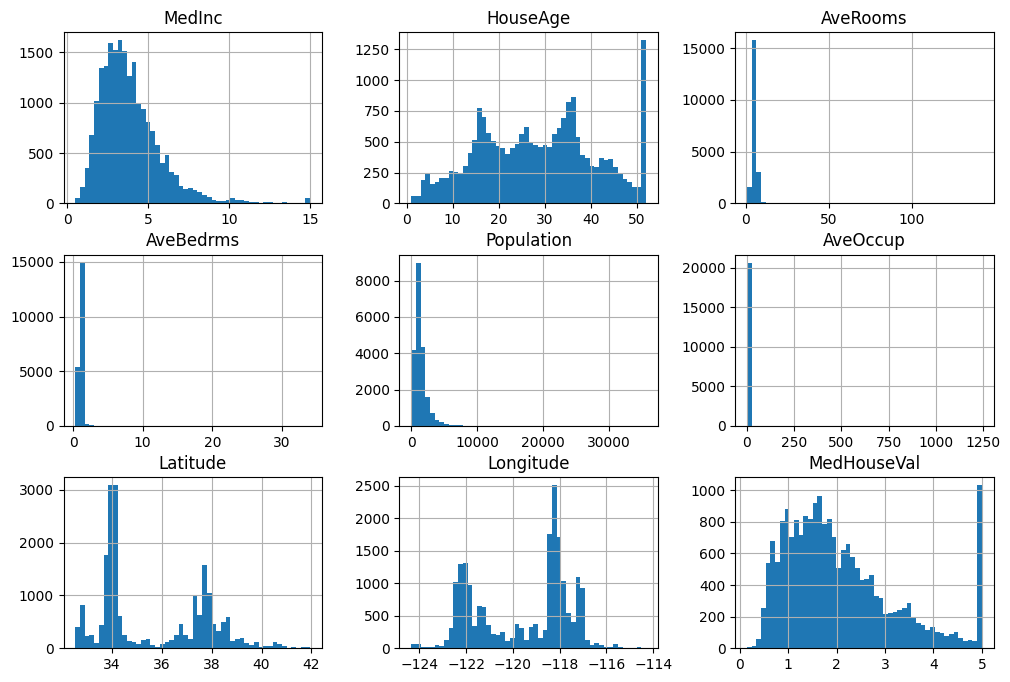

In [ ]:
import matplotlib.pyplot as plt
housing.frame.hist(bins=50,figsize=(12,8))
plt.show()

In [ ]:
X=house_price_df.drop('MedHouseVal',axis=1)
y=house_price_df['MedHouseVal']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)
print(f"training data shape {x_train.shape}")
print(f"testing data shape {x_test.shape}")
model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-validation R2 scores:", cv_scores)
print("Mean CV R2 score:", cv_scores.mean())


training data shape (18576, 8)
testing data shape (2064, 8)
Mean Squared Error: 0.5590
R-squared: 0.5808
Cross-validation R2 scores: [0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean CV R2 score: 0.5530311140279569


In [ ]:
print("\n---Model Evaluation---")
print(f"Model intercept(B): {model.intercept_:.4f}")
print(f"Model coefficients(M): {model.coef_}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

sample_house=np.array([[2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46]])
predicted_price_100k=model.predict(sample_house)

predicted_price_actual=predicted_price_100k[0]*100000

print(f"\nPredicted house value in 100k: ${predicted_price_100k[0]:.2f}")
print(f"Predicted house value in actual: ${predicted_price_actual:,.2f}")


---Model Evaluation---
Model intercept(B): -36.7196
Model coefficients(M): [ 4.41643302e-01  9.57511565e-03 -1.10367141e-01  6.52574143e-01
 -4.32296453e-06 -3.61976686e-03 -4.18702648e-01 -4.31747018e-01]
Mean Squared Error: 0.56
R-squared: 0.58

Predicted house value in 100k: $1.76
Predicted house value in actual: $175,506.41


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
sfs=SequentialFeatureSelector(model,n_features_to_select=4,direction='backward',cv=15,n_jobs=-1)
sfs.fit(x_train,y_train)
print(f"Selected features: {sfs.get_feature_names_out()}")
selected_features=X.columns[sfs.get_support()]
print(f"Selected features: {selected_features}")


Selected features: ['MedInc' 'HouseAge' 'Latitude' 'Longitude']
Selected features: Index(['MedInc', 'HouseAge', 'Latitude', 'Longitude'], dtype='object')


In [ ]:
X_train_selected=sfs.transform(x_train)
X_test_selected=sfs.transform(x_test)
model.fit(X_train_selected,y_train)
print(f"Model R^2 score with selected features: {model.score(X_test_selected,y_test):.4f}")
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='r2')
print("Cross-validation R2 scores (selected features):", cv_scores)
print("Mean CV R2 score:", cv_scores.mean())


Model R^2 score with selected features: 0.5718
Cross-validation R2 scores (selected features): [0.61107614 0.58595256 0.59261176 0.60788297 0.58451879]
Mean CV R2 score: 0.5964084458093544


In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
pca=PCA(n_components=0.95)
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)
print(f"Original number of features: {X.shape[1]}")
print(f"Number of components kept for 95% variance: {pca.n_components_}")
print(f"Explained variance ratio for each component: {pca.explained_variance_ratio_}")

lr=LinearRegression()
lr.fit(x_train_pca,y_train)
score=lr.score(x_test_pca,y_test)
print(f"\nModel R^2 score using PCA components: {score:.4f}")

Original number of features: 8
Number of components kept for 95% variance: 6
Explained variance ratio for each component: [0.25351093 0.2346866  0.15922551 0.12860831 0.12546505 0.08281622]

Model R^2 score using PCA components: 0.4830


In [ ]:
from sklearn.model_selection import cross_val_score

X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)

cv_scores = cross_val_score(lr, X_pca, y, cv=5, scoring='r2')
print("Cross-validation R2 scores (PCA):", cv_scores)
print("Mean CV R2 score:", cv_scores.mean())

Cross-validation R2 scores (PCA): [0.45718681 0.37999705 0.47471982 0.34685988 0.49941592]
Mean CV R2 score: 0.4316358937570812


In [8]:
import numpy as np
import matplotlib.pyplot as plt
x= np.array([1,2,3,4,5])
y=np.array([2,2.5,3.5,4,4.5])
m=len(x)
w0=0.5
w1=0.5
learning_rate=0.001
iterations=200
loss_history=[]
w0_history=[]
w1_history=[]
for i in range(iterations):
  y_pred=w0+w1*x
  dw0=-(1/m)*np.sum(y-y_pred)
  dw1=-(1/m)*np.sum((y-y_pred)*x)
  w0=w0-learning_rate*dw0
  w1=w1-learning_rate*dw1
  mse=np.mean((y-y_pred)**2)
  loss_history.append(mse)
  w0_history.append(w0)
  w1_history.append(w1)



print("\nFinal Parameters:")
print(f"w0(BIAS)={w0:.4f}")
print(f"w1 (slope)={w1:.4f}")


Final Parameters:
w0(BIAS)=0.6149
w1 (slope)=0.8179


In [ ]:
y_final_pred = w0 + w1 * x
final_mse = np.mean((y - y_final_pred)**2)

print("Final Predictions:", y_final_pred)
print("Final MSE:", final_mse)

Final Predictions: [1.43287986 2.25081733 3.06875481 3.88669229 4.70462976]
Final MSE: 0.12488032940427067


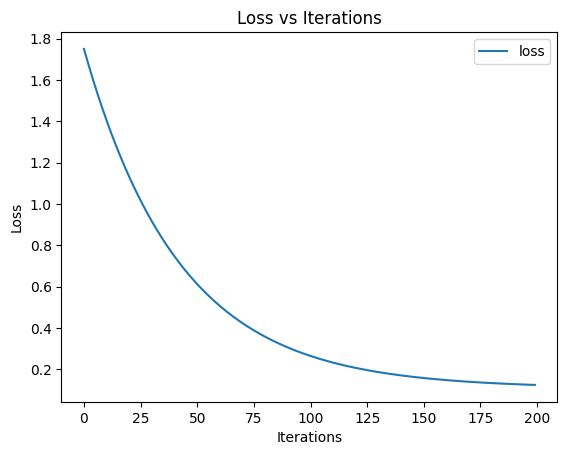

In [ ]:
plt.plot(range(iterations),loss_history,label="loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.legend()
plt.show()

In [3]:
import numpy as np
X = np.array([[1,2],
              [3,4],
              [5,6]])

y = np.array([10,13,16])

X_T = X.T
beta = np.linalg.pinv(X_T.dot(X)).dot(X_T).dot(y)

print("Coefficients:", beta)

Coefficients: [-7.   8.5]


In [ ]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import RidgeCV,LassoCV
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
ridge=Ridge(alpha=10)
lasso=Lasso(alpha=0.001)
ridge.fit(x_train_scaled,y_train)
lasso.fit(x_train_scaled,y_train)
ridge_pred=ridge.predict(x_test_scaled)
lasso_pred=lasso.predict(x_test_scaled)
print(f"Ridge MSE:{mean_squared_error(y_test,ridge_pred):.4f}")
print(f"Ridge R2 score:{r2_score(y_test,ridge_pred):.4f}")
print(f"Lasso MSE:{mean_squared_error(y_test,lasso_pred):.4f}")
print(f"Lasso R2 score:{r2_score(y_test,lasso_pred):.4f}")


Ridge MSE:0.5590
Ridge R2 score:0.5808
Lasso MSE:0.5589
Lasso R2 score:0.5809


In [ ]:
alphas=[0.001,0.01,0.1,1,10]
ridge_cv=RidgeCV(alphas=alphas,cv=5)
lasso_cv=LassoCV(alphas=alphas,cv=5)
ridge_cv.fit(x_train_scaled,y_train)
lasso_cv.fit(x_train_scaled,y_train)
print(f"Ridge CV best alpha:{ridge_cv.alpha_:.4f}")
print(f"Lasso CV best alpha:{lasso_cv.alpha_:.4f}")

Ridge CV best alpha:10.0000
Lasso CV best alpha:0.0010



Polynomial Degree 1
 Training MSE: 0.2303
 Testing MSE: 0.2165
 Training R2: 0.4666
 Testing R2: 0.4974

Polynomial Degree 3
 Training MSE: 0.0678
 Testing MSE: 0.0757
 Training R2: 0.8429
 Testing R2: 0.8243

Polynomial Degree 5
 Training MSE: 0.0602
 Testing MSE: 0.0694
 Training R2: 0.8607
 Testing R2: 0.8389

Polynomial Degree 10
 Training MSE: 0.0380
 Testing MSE: 0.1201
 Training R2: 0.9119
 Testing R2: 0.7212


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


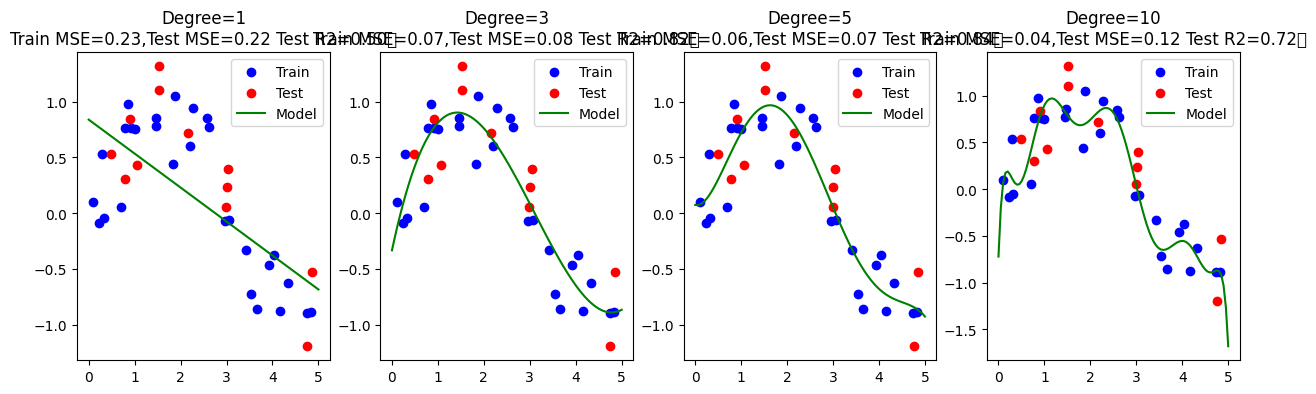

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
np.random.seed(42)
X=np.sort(5*np.random.rand(40,1),axis=0)
y=np.sin(X).ravel()+0.3*np.random.randn(40)
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.3, random_state=42)
degrees=[1,3,5,10]
plt.figure(figsize=(15,4))
for i,d in enumerate(degrees):
  poly=PolynomialFeatures(degree=d)
  X_poly_train=poly.fit_transform(X_train)
  X_poly_test=poly.transform(X_test)
  model=LinearRegression()
  model.fit(X_poly_train,y_train)
  y_train_pred=model.predict(X_poly_train)
  y_test_pred=model.predict(X_poly_test)
  train_error= mean_squared_error(y_train,y_train_pred)
  test_error=mean_squared_error(y_test,y_test_pred)
  train_r2=r2_score(y_train,y_train_pred)
  test_r2=r2_score(y_test,y_test_pred)
  print(f"\nPolynomial Degree {d}")
  print(f" Training MSE: {train_error:.4f}")
  print(f" Testing MSE: {test_error:.4f}")
  print(f" Training R2: {train_r2:.4f}")
  print(f" Testing R2: {test_r2:.4f}")
  plt.subplot(1,4,i+1)
  plt.scatter(X_train,y_train,color="blue",label="Train")
  plt.scatter(X_test,y_test,color="red",label="Test")
  X_plot=np.linspace(0,5,100).reshape(-1,1)
  plt.plot(X_plot,model.predict(poly.transform(X_plot)),color="green",label="Model")
  plt.title(f"Degree={d}\nTrain MSE={train_error:.2f},Test MSE={test_error:.2f} Test R2={test_r2:.2f}\t")
  plt.legend()
plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
iris=load_iris()
x=iris.data
y=iris.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"KNN Model Accuracy:{accuracy:.4f}")
print("\nSample Predictions")
for i in range(5):
  print(f"Actual:{iris.target_names[y_test[i]]},Predicted:{iris.target_names[y_pred[i]]}")

KNN Model Accuracy:1.0000

Sample Predictions
Actual:versicolor,Predicted:versicolor
Actual:setosa,Predicted:setosa
Actual:virginica,Predicted:virginica
Actual:versicolor,Predicted:versicolor
Actual:versicolor,Predicted:versicolor


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

# Cross Validation
cv_scores = cross_val_score(knn, x, y, cv=5, scoring='accuracy')
print("\nCross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report (Precision, Recall, F1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# AUC (multi-class)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_bin = label_binarize(y_pred, classes=[0,1,2])
auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr')
print("AUC Score:", auc)

# Error Rate
error = 1 - accuracy
print("Error Rate:", error)


Cross-validation scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean CV accuracy: 0.9733333333333334

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

AUC Score: 1.0
Error Rate: 0.0


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
iris=load_iris()
x=iris.data
y=iris.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
dt= DecisionTreeClassifier(criterion='log_loss',splitter='best',max_depth=None,min_samples_split=2,min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.01, monotonic_cst=None)
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)


accuracy=accuracy_score(y_test,y_pred)
cv_scores = cross_val_score(dt, x, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print(f"Accuracy:{accuracy:.4f}")

Cross-validation scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Mean CV accuracy: 0.9533333333333334
Accuracy:1.0000


[Text(0.3076923076923077, 0.9285714285714286, 'x[2] <= 2.45\nlog_loss = 1.585\nsamples = 120\nvalue = [40, 41, 39]'),
 Text(0.23076923076923078, 0.7857142857142857, 'log_loss = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\nlog_loss = 1.0\nsamples = 80\nvalue = [0, 41, 39]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\nlog_loss = 0.179\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.07692307692307693, 0.5, 'log_loss = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.23076923076923078, 0.5, 'log_loss = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\nlog_loss = 0.519\nsamples = 43\nvalue = [0, 5, 38]'),
 Text(0.38461538461538464, 0.5, 'x[2] <= 4.95\nlog_loss = 1.0\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'log_los

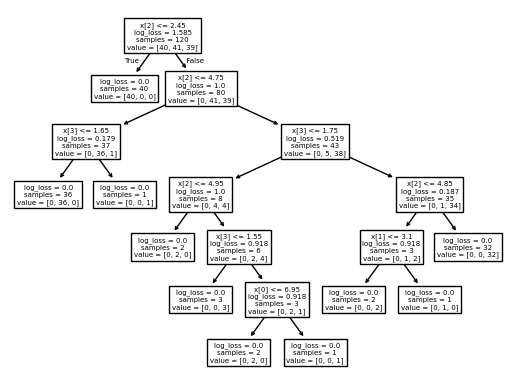

In [ ]:
tree.plot_tree(dt)

D:\Users\Max\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\Max\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\Max\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\Max\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

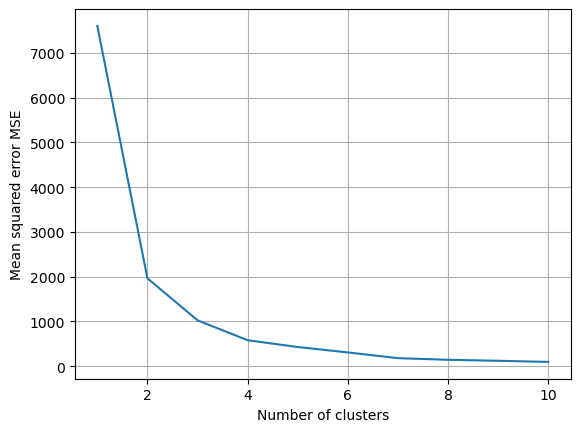

D:\Users\Max\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


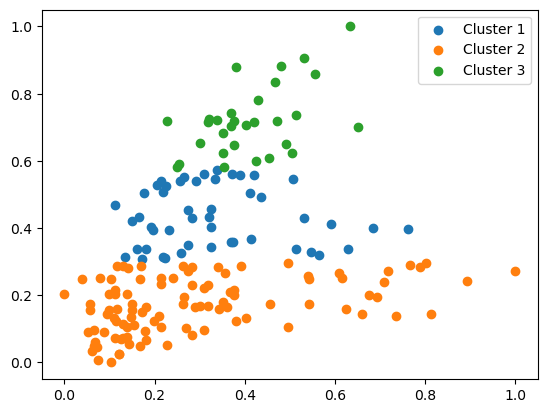

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

wine = load_wine()
X = pd.DataFrame(wine.data, columns = wine.feature_names)
X[:5]

mse = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X)
  mse.append(mean_squared_error(X, kmeans.cluster_centers_[kmeans.labels_]))

plt.plot(range(1,11),mse)
plt.grid(True)
plt.xlabel("Number of clusters")
plt.ylabel("Mean squared error MSE")
plt.show()

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.labels_
labels

scaler = MinMaxScaler()
normalized_X = scaler.fit_transform(X)

for j in range(3):
    plt.scatter(normalized_X[labels == j, 9], normalized_X[labels == j, 12], label=f'Cluster {j+1}')
    plt.legend()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
# Load data
iris = load_iris()
x = iris.data
y = iris.target
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

ann = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
# Train
ann.fit(x_train_scaled, y_train)
# Predict
y_pred = ann.predict(x_test_scaled)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"ANN Accuracy: {accuracy:.4f}")
# Cross-validation
x_scaled = scaler.fit_transform(x)
cv_scores = cross_val_score(ann, x_scaled, y, cv=5, scoring='accuracy')
print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ANN Accuracy: 1.0000
CV scores: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Mean CV accuracy: 0.9666666666666668

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [13]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score,roc_auc_score

iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)

model=GaussianNB()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)

cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

error=1-accuracy
print("Error:",error)

y_test_bin=(y_test==1).astype(int)
y_pred_bin=(y_pred==1).astype(int)
y_prob_bin=y_prob[:,1]

tn,fp,fn,tp=confusion_matrix(y_test_bin,y_pred_bin).ravel()

print("TP:",tp)
print("TN:",tn)
print("FP:",fp)
print("FN:",fn)

recall=recall_score(y_test_bin,y_pred_bin)
print("Recall:",recall)

specificity=tn/(tn+fp)
print("Specificity:",specificity)

f1=f1_score(y_test_bin,y_pred_bin)
print("F1 Score:",f1)

auc=roc_auc_score(y_test_bin,y_prob_bin)
print("AUC:",auc)

kf=KFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(model,X,y,cv=kf,scoring='accuracy')

print("K-Fold Accuracies:",cv_scores)
print("Mean Accuracy:",np.mean(cv_scores))

Confusion Matrix:
 [[23  0  0]
 [ 0 18  1]
 [ 0  1 17]]
Accuracy: 0.9666666666666667
Error: 0.033333333333333326
TP: 18
TN: 40
FP: 1
FN: 1
Recall: 0.9473684210526315
Specificity: 0.975609756097561
F1 Score: 0.9473684210526315
AUC: 0.9987163029525032
K-Fold Accuracies: [1.         0.96666667 0.93333333 0.96666667 0.93333333]
Mean Accuracy: 0.9600000000000002


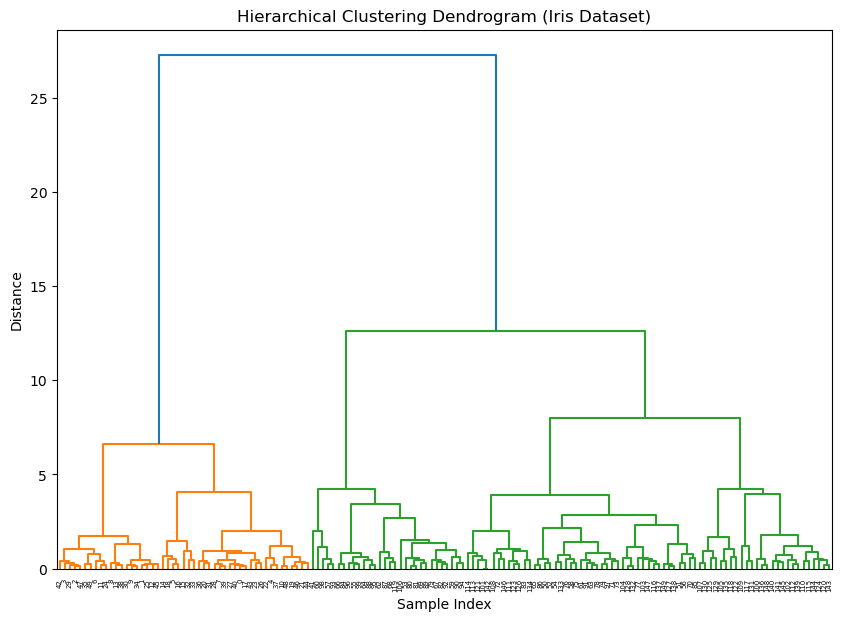

In [12]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    orientation='top',
    distance_sort='ascending',
    show_leaf_counts=True
)

plt.title('Hierarchical Clustering Dendrogram (Iris Dataset)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [ ]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import SGDClassifier

# Load dataset
diabetes = datasets.load_diabetes()

X = diabetes.data
y = diabetes.target

# Convert regression target → classification (binary)
threshold = y.mean()
y = (y > threshold).astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression model
reg = linear_model.LogisticRegression(max_iter=1000)
reg.fit(X_train, y_train)

# Predictions
y_pred = reg.predict(X_test)

# Accuracy
print("Logistic Regression accuracy:",
      metrics.accuracy_score(y_test, y_pred) * 100)

# SGD Classifier (logistic loss)
clf = SGDClassifier(loss="log_loss", penalty="l1", max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred1 = clf.predict(X_test)

print("SGD Classifier accuracy:",
      metrics.accuracy_score(y_test, y_pred1) * 100)

Logistic Regression accuracy: 76.40449438202246
SGD Classifier accuracy: 69.66292134831461


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
x = iris.data
y = iris.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

svm = SVC(kernel='linear', probability=True)
svm.fit(x_train_scaled,y_train)

y_pred = svm.predict(x_test_scaled)

accuracy = accuracy_score(y_test,y_pred)
print(f"SVM Accuracy:{accuracy:.4f}")

cv_scores = cross_val_score(svm, scaler.fit_transform(x), y, cv=5, scoring='accuracy')
print("CV scores:",cv_scores)
print("Mean CV accuracy:",cv_scores.mean())

print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

SVM Accuracy:0.9778
CV scores: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Mean CV accuracy: 0.9666666666666668

Confusion Matrix:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

